In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr
from scipy.stats import uniform, randint
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

In [51]:
# 한글 표시
plt.rcParams['font.family'] = "Gulim"
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드 및 기본 정보 확인

In [52]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')

# 타겟 변수 설정 - 명확한 명명
target_names = ['Leaf_TPC', 'Root_TPC', 'Leaf_TFC', 'Root_TFC']  
y_targets = df_merged[target_names].copy()

In [53]:
# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

### Feature Engineering

In [54]:
# 특성 그룹 정의
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

In [55]:
# 원본 특성
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

In [56]:
# 엔지니어링된 특성 추가
X_engineered = X_original.copy()

In [57]:
# 1. 생육 단계 (월별) - 천궁의 생장 패턴 반영
growth_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X_engineered['growth_stage'] = [growth_map[m] for m in months]
X_engineered['growth_stage_sq'] = X_engineered['growth_stage'] ** 2
X_engineered['growth_stage_log'] = np.log1p(X_engineered['growth_stage'])

In [58]:
# 시계열 특성 (월별 사인/코사인)
X_engineered['month_sin'] = np.sin(2 * np.pi * months / 12)
X_engineered['month_cos'] = np.cos(2 * np.pi * months / 12)

In [59]:
# 2. 시나리오 정보 - 원핫 인코딩
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'is_{scenario}'] = (scenarios == scenario).astype(int)

In [60]:
# 3. 온도 관련 특성 (천궁 최적 온도 15-25°C)
optimal_temp = 22
X_engineered['temp_deviation'] = np.abs(X_engineered['Temp'] - optimal_temp)
X_engineered['temp_optimal'] = np.exp(-((X_engineered['Temp'] - optimal_temp) ** 2) / (2 * 5**2))
X_engineered['heat_stress'] = np.where(X_engineered['Temp'] > 28, X_engineered['Temp'] - 28, 0)
X_engineered['cold_stress'] = np.where(X_engineered['Temp'] < 15, 15 - X_engineered['Temp'], 0)

In [61]:
# 4. VPD 관련 특성 (수분 스트레스)
optimal_vpd = 1.0
X_engineered['vpd_stress'] = np.where(X_engineered['VPD'] > 1.5, X_engineered['VPD'] - 1.5, 0)
X_engineered['vpd_optimal'] = np.exp(-((X_engineered['VPD'] - optimal_vpd) ** 2) / (2 * 0.5**2))
X_engineered['drought_stress'] = X_engineered['VPD'] * (100 - X_engineered['Humid']) / 100

In [62]:
# 5. CO2 관련 특성
baseline_co2 = 432  # 현재 대기 CO2 농도
X_engineered['co2_enrichment'] = X_engineered['CO2ppm'] - baseline_co2
X_engineered['co2_effect'] = np.log1p(X_engineered['CO2ppm'] / baseline_co2)
X_engineered['co2_saturation'] = 1 - np.exp(-X_engineered['CO2ppm'] / 1000)

In [63]:
# 6. 광합성 효율 지표
X_engineered['photosyn_efficiency'] = X_engineered['PI_abs'] * X_engineered['Fv-Fm']
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)
X_engineered['energy_flux'] = X_engineered['Eto-RC'] / (X_engineered['Tro-RC'] + 1e-10)
X_engineered['light_use_efficiency'] = X_engineered['Eto-RC'] / (X_engineered['ABS-RC'] + 1e-10)
X_engineered['photosyn_capacity'] = X_engineered['TChl'] * X_engineered['Fv-Fm']

In [64]:
# 7. 클로로필 관련 지표 (중복 제거)
# Chl_a_b는 이미 Chl_a/Chl_b 비율이므로 chl_ratio 제거
X_engineered['car_ratio'] = X_engineered['Car'] / (X_engineered['TChl'] + 1e-10)
X_engineered['pigment_total'] = X_engineered['TChl'] + X_engineered['Car']
X_engineered['chl_per_car'] = X_engineered['TChl'] / (X_engineered['Car'] + 1e-10)
X_engineered['car_protection'] = X_engineered['Car'] / (X_engineered['pigment_total'] + 1e-10)
X_engineered['chl_balance'] = (X_engineered['Chl_a'] - X_engineered['Chl_b']) / (X_engineered['TChl'] + 1e-10)

In [65]:
# 8. 환경 상호작용 특성
X_engineered['temp_x_co2'] = X_engineered['Temp'] * X_engineered['CO2ppm'] / 1000
X_engineered['vpd_x_temp'] = X_engineered['VPD'] * X_engineered['Temp']
X_engineered['humid_x_temp'] = X_engineered['Humid'] * X_engineered['Temp'] / 100

In [66]:
# 9. 환경 적응 지표
X_engineered['env_favorability'] = (X_engineered['temp_optimal'] * X_engineered['vpd_optimal'])
X_engineered['stress_index'] = (X_engineered['heat_stress'] + X_engineered['cold_stress'] + 
                                X_engineered['vpd_stress']) / 3

In [67]:
# 10. 극한 기후 시나리오(SSP5) 특별 상호작용
X_engineered['extreme_temp'] = X_engineered['Temp'] * X_engineered['is_SSP5']
X_engineered['extreme_co2'] = X_engineered['CO2ppm'] * X_engineered['is_SSP5'] / 1000
X_engineered['extreme_stress'] = X_engineered['stress_index'] * X_engineered['is_SSP5']

In [68]:
print(f"\n엔지니어링 후 특성 수: {X_engineered.shape[1]}")
print(f"추가된 특성 수: {X_engineered.shape[1] - len(original_features)}")


엔지니어링 후 특성 수: 54
추가된 특성 수: 36


### 다중공선성 체크 및 제거

In [69]:
def check_multicollinearity(X, threshold=10):
    """VIF를 사용한 다중공선성 체크 및 문제 변수 제거"""
    print(f"VIF 임계값: {threshold}")
    print("계산 중... (시간이 걸릴 수 있습니다)")
    
    # 수치형 데이터만 선택
    X_numeric = X.select_dtypes(include=[np.number])
    
    # VIF 계산
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_numeric.columns
    vif_values = []
    
    for i in range(len(X_numeric.columns)):
        try:
            vif = variance_inflation_factor(X_numeric.values, i)
            vif_values.append(vif)
        except:
            vif_values.append(np.inf)
    
    vif_data["VIF"] = vif_values
    
    # 무한대 값 처리
    vif_data = vif_data[vif_data['VIF'] != np.inf]
    
    # VIF 기준 정렬
    vif_data = vif_data.sort_values('VIF', ascending=False)
    
    print("\n상위 10개 VIF 값:")
    print(vif_data.head(10).to_string(index=False))
    
    # 문제가 있는 변수 식별
    problematic = vif_data[vif_data['VIF'] > threshold]
    
    if not problematic.empty:
        print(f"\n⚠️ VIF > {threshold}인 변수 ({len(problematic)}개):")
        for _, row in problematic.iterrows():
            print(f"  - {row['Feature']}: VIF = {row['VIF']:.2f}")
        
        # 중요한 원본 특성은 유지, 엔지니어링된 특성 중 VIF가 높은 것만 제거
        features_to_drop = []
        for feat in problematic['Feature'].values:
            if feat not in original_features:
                features_to_drop.append(feat)
        
        if features_to_drop:
            print(f"\n제거할 특성 ({len(features_to_drop)}개): {features_to_drop}")
            X_cleaned = X.drop(columns=features_to_drop)
            return X_cleaned, vif_data
    else:
        print(f"\n✅ 모든 변수의 VIF가 {threshold} 이하입니다.")
    
    return X, vif_data

In [70]:
# 다중공선성 체크 실행
X_cleaned, vif_results = check_multicollinearity(X_engineered, threshold=10)
print(f"\n최종 특성 수: {X_cleaned.shape[1]}")

VIF 임계값: 10
계산 중... (시간이 걸릴 수 있습니다)

상위 10개 VIF 값:
       Feature          VIF
    vpd_x_temp 3.796977e+06
        ABS-RC 2.823653e+06
          Temp 2.249616e+06
    co2_effect 2.126917e+06
co2_saturation 1.823358e+06
        Tro-RC 1.166918e+06
        Dio-RC 4.774864e+05
   vpd_optimal 3.026953e+05
         Chl_a 3.012842e+05
  extreme_temp 2.632894e+05

⚠️ VIF > 10인 변수 (36개):
  - vpd_x_temp: VIF = 3796976.65
  - ABS-RC: VIF = 2823652.88
  - Temp: VIF = 2249616.44
  - co2_effect: VIF = 2126916.89
  - co2_saturation: VIF = 1823358.28
  - Tro-RC: VIF = 1166918.44
  - Dio-RC: VIF = 477486.40
  - vpd_optimal: VIF = 302695.26
  - Chl_a: VIF = 301284.18
  - extreme_temp: VIF = 263289.40
  - drought_stress: VIF = 244649.09
  - humid_x_temp: VIF = 124585.37
  - PI_abs: VIF = 72710.17
  - photosyn_efficiency: VIF = 67043.04
  - energy_dissipation: VIF = 48548.58
  - Fv-Fm: VIF = 41983.97
  - temp_optimal: VIF = 40713.54
  - car_protection: VIF = 32129.88
  - Humid: VIF = 31734.70
  - extreme

In [71]:
# 최종 사용할 특성 설정
X_final = X_cleaned
X_final.columns

Index(['CO2ppm', 'Temp', 'Humid', 'VPD', 'Chl_a', 'Chl_b', 'TChl', 'Car',
       'Chl_a_b', 'TCh-Car', 'ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs',
       'DF_abs', 'SFI_abs', 'Fv-Fm', 'growth_stage', 'growth_stage_sq',
       'growth_stage_log', 'month_sin', 'month_cos', 'is_SSP1', 'is_SSP3',
       'is_SSP5', 'heat_stress', 'cold_stress', 'vpd_stress', 'co2_enrichment',
       'pigment_total', 'stress_index'],
      dtype='object')

### 상관관계 분석 (개선된 버전)

In [72]:
# 전체 데이터 상관관계 분석
correlation_summary = pd.DataFrame()

for target in target_names:
    correlations = []
    for feature in X_final.columns:
        corr, p_value = pearsonr(X_final[feature], y_targets[target])
        correlations.append({
            'Feature': feature,
            'Target': target,
            'Correlation': corr,
            'Abs_Correlation': abs(corr),
            'P_value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    
    df_corr = pd.DataFrame(correlations)
    df_corr = df_corr[df_corr['Significant'] == 'Yes'].sort_values('Abs_Correlation', ascending=False)
    
    print(f"\n{target} - Top 10 상관관계:")
    print(df_corr[['Feature', 'Correlation', 'P_value']].head(10).to_string(index=False))
    
    correlation_summary = pd.concat([correlation_summary, df_corr.head(10)])


Leaf_TPC - Top 10 상관관계:
        Feature  Correlation      P_value
      month_cos    -0.581994 4.365302e-38
growth_stage_sq    -0.470165 1.152649e-23
        TCh-Car    -0.441342 9.803900e-21
   growth_stage    -0.377048 3.955298e-15
          Chl_a    -0.353476 2.309687e-13
        SFI_abs     0.349494 4.443919e-13
         PI_abs     0.348075 5.598601e-13
           TChl    -0.335736 3.974730e-12
         DF_abs     0.322081 3.148204e-11
        is_SSP1    -0.316454 7.170145e-11

Root_TPC - Top 10 상관관계:
         Feature  Correlation      P_value
growth_stage_log    -0.756661 2.216563e-76
       month_sin     0.756506 2.475524e-76
    growth_stage    -0.695461 8.148276e-60
            Temp    -0.659459 6.822039e-52
      vpd_stress    -0.635521 3.333894e-47
    stress_index    -0.635521 3.333894e-47
             VPD    -0.635521 3.333894e-47
 growth_stage_sq    -0.605091 8.272029e-42
             Car     0.592151 1.096651e-39
           Humid     0.543758 1.540240e-32

Leaf_TFC - Top

### 성능 평가 지표 정의

In [73]:
def safe_float(value):
    """안전한 float 변환"""
    if isinstance(value, (pd.Series, pd.DataFrame)):
        return float(value.iloc[0]) if len(value) == 1 else float(value.mean())
    elif isinstance(value, np.ndarray):
        return float(value.item()) if value.size == 1 else float(value.mean())
    else:
        return float(value)

In [74]:
def calculate_mape(y_true, y_pred, eps=1e-9):
    """Mean Absolute Percentage Error"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

In [75]:
def calculate_pi(y_true, y_pred):
    """Performance Index (Nash-Sutcliffe Efficiency)"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

In [76]:
def calculate_comprehensive_metrics(y_true, y_pred):
    """모든 평가지표 계산"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    y_true_pos = np.maximum(y_true, 0)
    y_pred_pos = np.maximum(y_pred, 0)
    msle = mean_squared_error(np.log1p(y_true_pos), np.log1p(y_pred_pos))
    rmsle = np.sqrt(msle)
    
    r2 = r2_score(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)
    pi = calculate_pi(y_true, y_pred)
    
    return {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse,
        'MSLE': msle, 'RMSLE': rmsle,
        'R2': r2, 'MAPE': mape, 'PI': pi
    }

### 하이퍼파라미터 최적화를 위한 파라미터 그리드 정의

In [77]:
# 공모전 제출용 파라미터 그리드 (실행시간: 2-3시간)
param_grids = {
    'RF': {
        'n_estimators': [500, 800],        # 3→2개 (충분한 성능)
        'max_depth': [None, 20],           # 3→2개 (깊이 제한)
        'min_samples_split': [2, 3],       # 3→2개 (핵심 값만)
        'min_samples_leaf': [1, 2],        # 유지 (과적합 방지)
        'max_features': ['sqrt', 0.8],     # 3→2개 (효과적 조합)
        'bootstrap': [True],
        'oob_score': [True],
        'random_state': [42]
    },
    
    'XGB': {
        'n_estimators': [800, 1200],       # 3→2개 (높은 성능 구간)
        'max_depth': [8, 10],              # 4→2개 (중간-깊음)
        'learning_rate': [0.03, 0.05],     # 4→2개 (안정적 구간)
        'subsample': [0.85, 0.9],          # 3→2개 (과적합 방지)
        'colsample_bytree': [0.8, 0.9],    # 3→2개 (특성 샘플링)
        'colsample_bylevel': [0.9],        # 2→1개 (단순화)
        'reg_alpha': [0.1],                # 3→1개 (적당한 정규화)
        'reg_lambda': [1.0],               # 3→1개 (L2 정규화)
        'min_child_weight': [2],           # 3→1개 (과적합 방지)
        'gamma': [0.1],                    # 3→1개 (분할 제한)
        'random_state': [42],
        'tree_method': ['hist'],           # 속도 향상
        'verbosity': [0]
    },
    
    'LGBM': {
        'n_estimators': [800, 1200],       # 3→2개 (고성능 구간)
        'num_leaves': [50, 80],            # 4→2개 (복잡성 제한)
        'max_depth': [12],                 # 3→1개 (적당한 깊이)
        'learning_rate': [0.03, 0.05],     # 4→2개 (안정적)
        'min_child_samples': [8, 12],      # 3→2개 (과적합 방지)
        'subsample': [0.85, 0.9],          # 3→2개 
        'colsample_bytree': [0.85],        # 3→1개 (단순화)
        'reg_alpha': [0.1],                # 3→1개 (L1 정규화)
        'reg_lambda': [0.5],               # 3→1개 (L2 정규화)
        'min_split_gain': [0.01],          # 3→1개 (분할 제한)
        'subsample_freq': [1],
        'random_state': [42],
        'verbosity': [-1],
        'force_col_wise': [True]           # 속도 향상
    },
    
    'GB': {
        'n_estimators': [500, 800],        # 3→2개 (충분한 성능)
        'max_depth': [7, 9],               # 4→2개 (중간 복잡도)
        'learning_rate': [0.05, 0.08],     # 4→2개 (효과적 구간)
        'subsample': [0.85, 0.9],          # 3→2개 (과적합 방지)
        'min_samples_split': [2, 3],       # 3→2개 (핵심 값)
        'min_samples_leaf': [1, 2],        # 3→2개 (단순화)
        'max_features': ['sqrt'],          # 2→1개 (단순화)
        'random_state': [42]
    }
}

# 실행 최적화 설정
optimization_config = {
    'cv_folds': 3,                    # 5→3 (40% 시간 단축)
    'n_jobs': -1,                     # 병렬 처리 최대화
    'verbose': 0,                     # 출력 최소화
    'early_stopping': True,           # 조기 종료 활성화
    'scoring': 'neg_mean_absolute_error'  # 공모전 주요 지표
}

In [78]:
print("하이퍼파라미터 최적화 대상 모델:")
for model_name, params in param_grids.items():
    print(f"  - {model_name}: {len(params)} 파라미터")

하이퍼파라미터 최적화 대상 모델:
  - RF: 8 파라미터
  - XGB: 13 파라미터
  - LGBM: 14 파라미터
  - GB: 8 파라미터


### 시나리오별 하이퍼파라미터 최적화 및 모델링

In [ ]:
# 기본 모델 정의
base_models = {
    'LinearR': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'kNN': KNeighborsRegressor(n_neighbors=3, weights='distance', metric='minkowski'),
    'SVM': SVR(kernel='rbf', C=10.0, epsilon=0.01, gamma='scale'),
    'DT': DecisionTreeRegressor(random_state=42),
    'RF': RandomForestRegressor(random_state=42, n_jobs=-1),
    'GB': GradientBoostingRegressor(random_state=42),
    'XGB': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbose=0),
    'LGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

SyntaxError: invalid non-printable character U+00A0 (20536975.py, line 3)

In [ ]:
# 멀티아웃풋을 기본 지원하는 모델들
NATIVE_MULTIOUTPUT = ['RF', 'DT', 'kNN']

In [ ]:
# 결과 저장
scenario_results = {}
cv_results = {}
best_models = {}
optimized_params = {}

# 교차검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{'='*60}")
    print(f"{scenario} 시나리오 모델링")
    print('='*60)
    
    # 데이터 준비
    scenario_mask = scenarios == scenario
    X_scenario = X_final[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    print(f"데이터 크기: {len(y_scenario)} samples")
    
    # Train/Test 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    # 스케일링
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    scenario_results[scenario] = {}
    cv_results[scenario] = {}
    optimized_params[scenario] = {}
    
    best_mae = float('inf')
    best_model_name = None
    best_model_obj = None
    
    # 각 모델 학습
    for model_name, base_model in base_models.items():
        print(f"\n{model_name} 모델:")
        
        try:
            from sklearn.base import clone
            
            # 하이퍼파라미터 최적화가 필요한 모델
            if model_name in param_grids:
                print(f"  하이퍼파라미터 최적화 진행...")
                
                # 간단한 그리드 서치 (시간 절약)
                if model_name not in NATIVE_MULTIOUTPUT:
                    # 첫 번째 타겟으로 최적화
                    search = GridSearchCV(
                        clone(base_model),
                        param_grids[model_name],
                        cv=3,
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1,
                        verbose=0
                    )
                    search.fit(X_train_scaled, y_train.iloc[:, 0])
                    best_params = search.best_params_
                    print(f"  최적 파라미터: {best_params}")
                    
                    model = clone(base_model).set_params(**best_params)
                    model = MultiOutputRegressor(model)
                else:
                    # Native multioutput은 간단히 처리
                    model = clone(base_model)
                    best_params = {}
                    
                optimized_params[scenario][model_name] = best_params
            else:
                # 최적화가 필요없는 단순 모델
                model = clone(base_model)
                if model_name not in NATIVE_MULTIOUTPUT:
                    model = MultiOutputRegressor(model)
                optimized_params[scenario][model_name] = {}
            
            # 교차검증
            cv_scores = []
            for train_idx, val_idx in kf.split(X_train_scaled):
                X_cv_train = X_train_scaled[train_idx]
                X_cv_val = X_train_scaled[val_idx]
                y_cv_train = y_train.iloc[train_idx]
                y_cv_val = y_train.iloc[val_idx]
                
                model_cv = clone(model)
                model_cv.fit(X_cv_train, y_cv_train)
                pred_cv = model_cv.predict(X_cv_val)
                cv_mae = mean_absolute_error(y_cv_val, pred_cv)
                cv_scores.append(cv_mae)
            
            cv_results[scenario][model_name] = {
                'mean': np.mean(cv_scores),
                'std': np.std(cv_scores)
            }
            
            # 전체 훈련 데이터로 학습
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_test_scaled)
            
            # 평가
            metrics = calculate_comprehensive_metrics(y_test, pred)
            scenario_results[scenario][model_name] = metrics
            
            # 출력
            print(f"  CV MAE: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
            print(f"  Test MAE: {safe_float(metrics['MAE']):.4f}")
            print(f"  Test R2: {safe_float(metrics['R2']):.4f}")
            
            # 최고 성능 모델 추적
            current_mae = safe_float(metrics['MAE'])
            if current_mae < best_mae:
                best_mae = current_mae
                best_model_name = model_name
                best_model_obj = clone(model)
                best_model_obj.fit(X_train_scaled, y_train)
                
        except Exception as e:
            print(f"  오류 발생: {e}")
            continue
    
    # 최고 모델 저장
    best_models[scenario] = {
        'model': best_model_obj,
        'scaler': scaler,
        'name': best_model_name,
        'params': optimized_params[scenario].get(best_model_name, {})
    }
    
    print(f"\n🏆 {scenario} 최고 성능 모델: {best_model_name}")
    print(f"   MAE: {best_mae:.4f}")
    if best_model_name in optimized_params[scenario]:
        if optimized_params[scenario][best_model_name]:
            print(f"   최적 파라미터: {optimized_params[scenario][best_model_name]}")


SSP1 시나리오 모델링
데이터 크기: 135 samples

LinearR 모델:
  CV MAE: 0.0887 ± 0.0183
  Test MAE: 0.0705
  Test R2: 0.9758

Ridge 모델:
  CV MAE: 0.1761 ± 0.0226
  Test MAE: 0.1579
  Test R2: 0.9499

kNN 모델:
  CV MAE: 0.1204 ± 0.0400
  Test MAE: 0.0606
  Test R2: 0.9798

SVM 모델:
  CV MAE: 0.1530 ± 0.0246
  Test MAE: 0.1341
  Test R2: 0.8962

DT 모델:
  CV MAE: 0.0825 ± 0.0125
  Test MAE: 0.0681
  Test R2: 0.9633

RF 모델:
  하이퍼파라미터 최적화 진행...
  CV MAE: 0.0720 ± 0.0090
  Test MAE: 0.0645
  Test R2: 0.9742

GB 모델:
  하이퍼파라미터 최적화 진행...
  최적 파라미터: {'learning_rate': 0.08, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500, 'random_state': 42, 'subsample': 0.85}
  CV MAE: 0.0762 ± 0.0089
  Test MAE: 0.0731
  Test R2: 0.9707

XGB 모델:
  하이퍼파라미터 최적화 진행...
  최적 파라미터: {'colsample_bylevel': 0.9, 'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 1200, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lam

### 특성 중요도 분석 (개선된 버전)

In [ ]:
feature_importance_all = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario} 시나리오 핵심인자:")
    
    # 최적화된 RandomForest 사용
    scenario_mask = scenarios == scenario
    X_scenario = X_final[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # 최적 파라미터가 있으면 사용
    if 'RF' in optimized_params[scenario] and optimized_params[scenario]['RF']:
        rf_params = optimized_params[scenario]['RF']
        rf = RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1)
    else:
        rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    
    rf.fit(X_scenario, y_scenario)
    
    # 특성 중요도
    importance = rf.feature_importances_
    feature_importance_all[scenario] = importance
    
    # 상위 15개 특성
    feature_importance_df = pd.DataFrame({
        'Feature': X_final.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance_df.head(15).to_string(index=False))


SSP1 시나리오 핵심인자:
         Feature  Importance
       month_cos    0.267949
    growth_stage    0.231925
 growth_stage_sq    0.167776
       month_sin    0.140192
growth_stage_log    0.120009
            TChl    0.009035
          Dio-RC    0.006420
             Car    0.006284
           Chl_b    0.006052
             VPD    0.005138
            Temp    0.005124
           Chl_a    0.004820
           Humid    0.004597
      vpd_stress    0.004522
   pigment_total    0.003834

SSP3 시나리오 핵심인자:
         Feature  Importance
       month_sin    0.220384
       month_cos    0.201140
growth_stage_log    0.188946
    growth_stage    0.179130
 growth_stage_sq    0.143246
          Dio-RC    0.007375
           Fv-Fm    0.006568
          ABS-RC    0.005398
          Tro-RC    0.005381
         SFI_abs    0.005204
             Car    0.005180
            Temp    0.004494
          DF_abs    0.004337
          PI_abs    0.004301
          Eto-RC    0.003623

SSP5 시나리오 핵심인자:
         Feature  Imp

### 결과 요약 테이블

In [ ]:
# 시나리오별 최고 성능 비교
summary_df = pd.DataFrame()

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results[scenario].items(), 
               key=lambda x: safe_float(x[1]['MAE']))
    
    summary_df = pd.concat([summary_df, pd.DataFrame({
        'Scenario': [scenario],
        'Best_Model': [best[0]],
        'MAE': [safe_float(best[1]['MAE'])],
        'RMSE': [safe_float(best[1]['RMSE'])],
        'R2': [safe_float(best[1]['R2'])],
        'PI': [safe_float(best[1]['PI'])],
        'MAPE': [safe_float(best[1]['MAPE'])]
    })])

print(summary_df.to_string(index=False))

Scenario Best_Model      MAE     RMSE       R2       PI     MAPE
    SSP1        kNN 0.060554 0.098192 0.979802 0.995907 1.281644
    SSP3         RF 0.052189 0.079079 0.972029 0.998292 1.206469
    SSP5         DT 0.031028 0.053795 0.951797 0.999004 0.649156


In [ ]:
# 전체 모델 성능 매트릭스
print("\n📊 전체 모델 성능 매트릭스 (MAE 기준):")
performance_matrix = pd.DataFrame()

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    for model_name in base_models.keys():
        if model_name in scenario_results[scenario]:
            mae = safe_float(scenario_results[scenario][model_name]['MAE'])
            r2 = safe_float(scenario_results[scenario][model_name]['R2'])
            
            performance_matrix = pd.concat([performance_matrix, pd.DataFrame({
                'Scenario': [scenario],
                'Model': [model_name],
                'MAE': [mae],
                'R2': [r2]
            })])

# 피벗 테이블로 변환
mae_pivot = performance_matrix.pivot(index='Model', columns='Scenario', values='MAE')
print("\nMAE by Model and Scenario:")
print(mae_pivot.round(4))


📊 전체 모델 성능 매트릭스 (MAE 기준):

MAE by Model and Scenario:
Scenario    SSP1    SSP3    SSP5
Model                           
DT        0.0681  0.0588  0.0310
GB        0.0731  0.0548  0.0321
LGBM      0.0762  0.0543  0.0347
LinearR   0.0705  0.0522  0.0330
RF        0.0645  0.0522  0.0344
Ridge     0.1579  0.1482  0.1808
SVM       0.1341  0.2069  0.2399
XGB       0.1199  0.0613  0.0580
kNN       0.0606  0.0918  0.1642


### 개별 시각화 (각 그래프 독립적으로)


그래프 1: 상관관계 히트맵 생성...


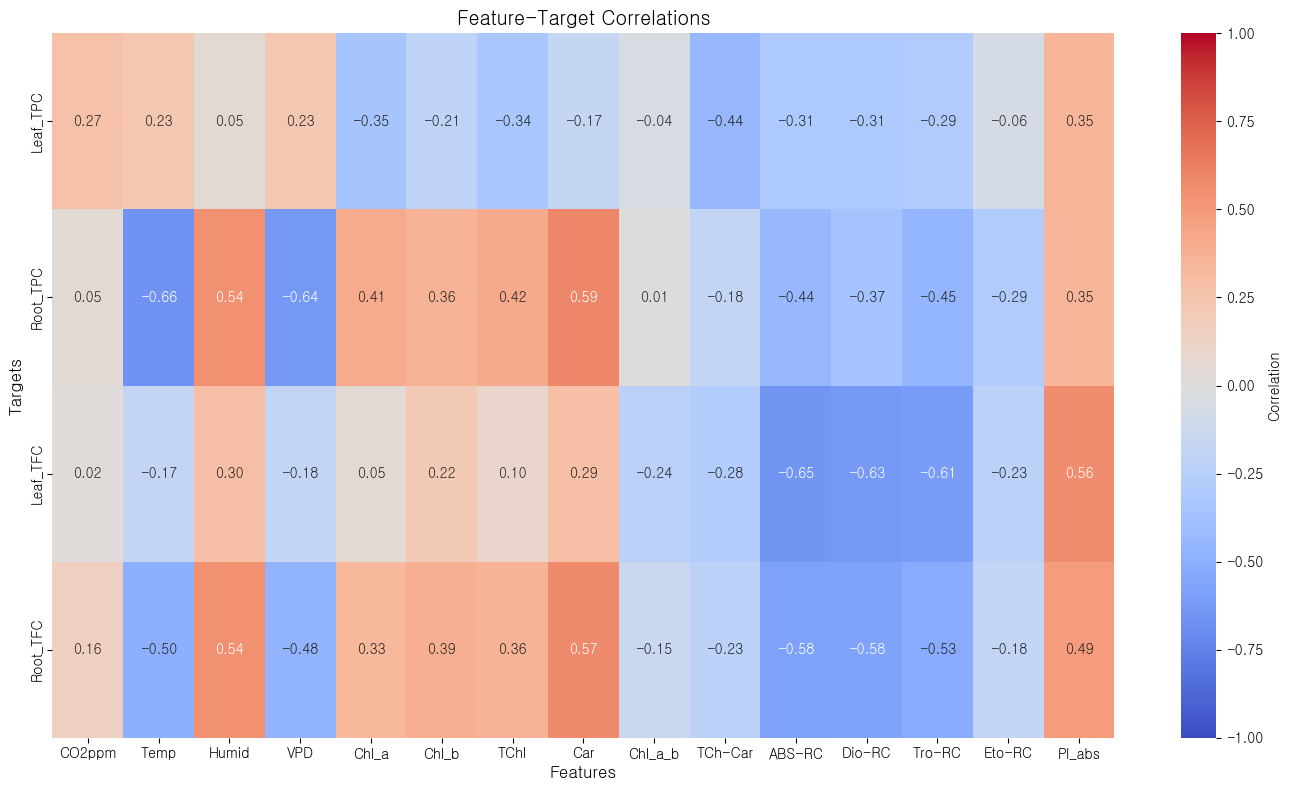

In [ ]:
# 색상 설정
colors_scenario = ['#2E7D32', '#F57C00', '#C62828']

# 1. 상관관계 히트맵
print("\n그래프 1: 상관관계 히트맵 생성...")
fig1, ax = plt.subplots(1, 1, figsize=(14, 8))
corr_data = pd.DataFrame()
# 주요 원본 특성 선택
selected_features = original_features[:15]
for feat in selected_features:
    if feat in X_final.columns:
        corr_data[feat] = X_final[feat]
for target in target_names:
    corr_data[target] = y_targets[target]

corr_matrix = corr_data.corr()
target_corr = corr_matrix[target_names].drop(target_names)

sns.heatmap(target_corr.T, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Correlation'}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature-Target Correlations', fontsize=14, fontweight='bold')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Targets', fontsize=12)
plt.tight_layout()
plt.show()

그래프 2: 모델별 MAE 비교...


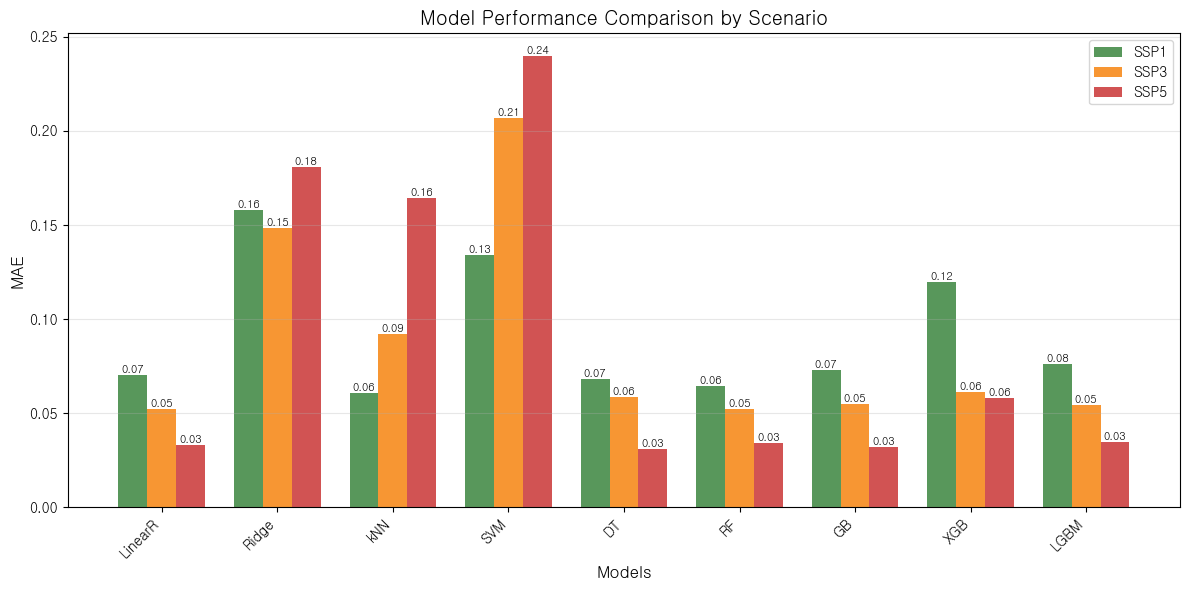

In [ ]:
# 2. 모델별 MAE 비교
print("그래프 2: 모델별 MAE 비교...")
fig2, ax = plt.subplots(1, 1, figsize=(12, 6))
x = np.arange(len(base_models))
width = 0.25

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    mae_values = [safe_float(scenario_results[scenario][model]['MAE']) 
                  for model in base_models.keys()]
    bars = ax.bar(x + i*width, mae_values, width, label=scenario, 
                  color=colors_scenario[i], alpha=0.8)
    
    # 값 표시
    for bar, val in zip(bars, mae_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Model Performance Comparison by Scenario', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(base_models.keys(), rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

그래프 3: R2 Score 트렌드...


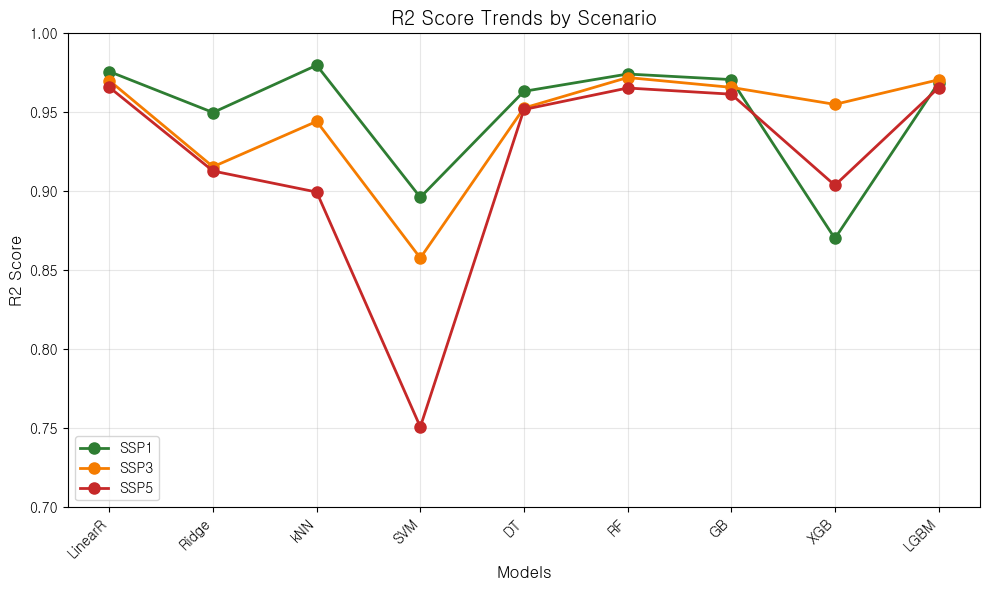

In [ ]:
# 3. R2 Score 트렌드
print("그래프 3: R2 Score 트렌드...")
fig3, ax = plt.subplots(1, 1, figsize=(10, 6))
for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    r2_values = [safe_float(scenario_results[scenario][model]['R2']) 
                 for model in base_models.keys()]
    ax.plot(base_models.keys(), r2_values, marker='o', label=scenario, 
            linewidth=2, markersize=8, color=colors_scenario[i])

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('R2 Score Trends by Scenario', fontsize=14, fontweight='bold')
ax.set_xticklabels(base_models.keys(), rotation=45, ha='right')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.7, 1.0])
plt.tight_layout()
plt.show()

그래프 4: Performance Index 히트맵...


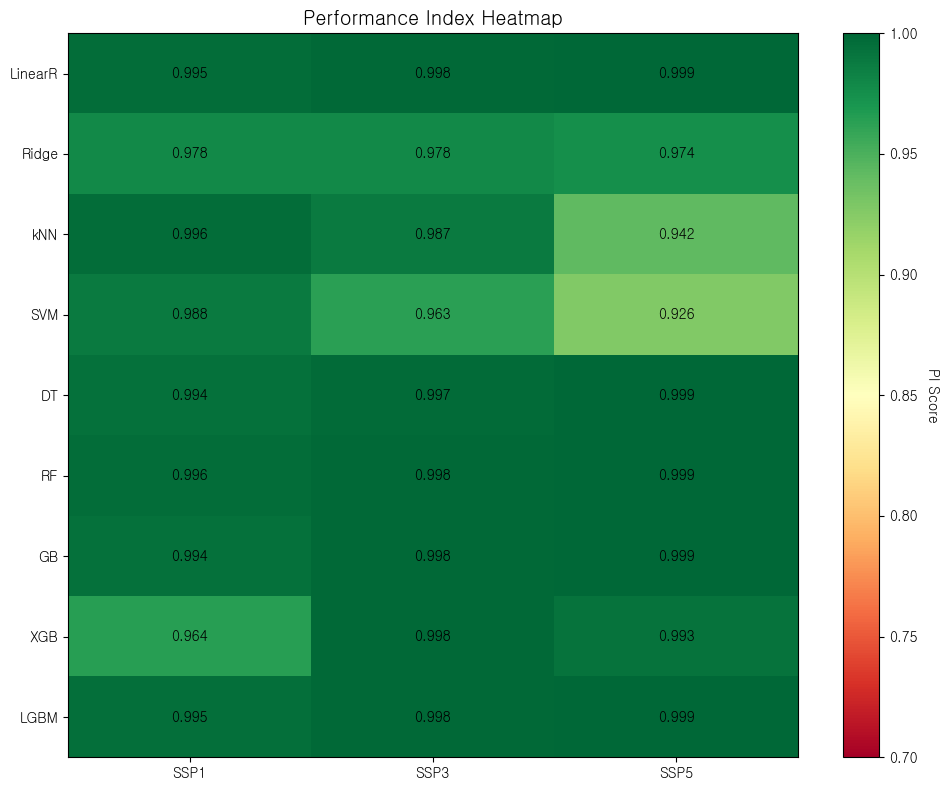

In [ ]:
# 4. Performance Index 히트맵
print("그래프 4: Performance Index 히트맵...")
fig4, ax = plt.subplots(1, 1, figsize=(10, 8))
pi_matrix = []
for model in base_models.keys():
    row = [safe_float(scenario_results[scenario][model]['PI']) 
           for scenario in ['SSP1', 'SSP3', 'SSP5']]
    pi_matrix.append(row)

im = ax.imshow(pi_matrix, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)
ax.set_xticks(range(3))
ax.set_xticklabels(['SSP1', 'SSP3', 'SSP5'])
ax.set_yticks(range(len(base_models)))
ax.set_yticklabels(base_models.keys())
ax.set_title('Performance Index Heatmap', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('PI Score', rotation=270, labelpad=15)

for i in range(len(base_models)):
    for j in range(3):
        text = ax.text(j, i, f'{pi_matrix[i][j]:.3f}',
                       ha="center", va="center", color="black", fontsize=10)
plt.tight_layout()
plt.show()

그래프 5: 특성 중요도 비교...


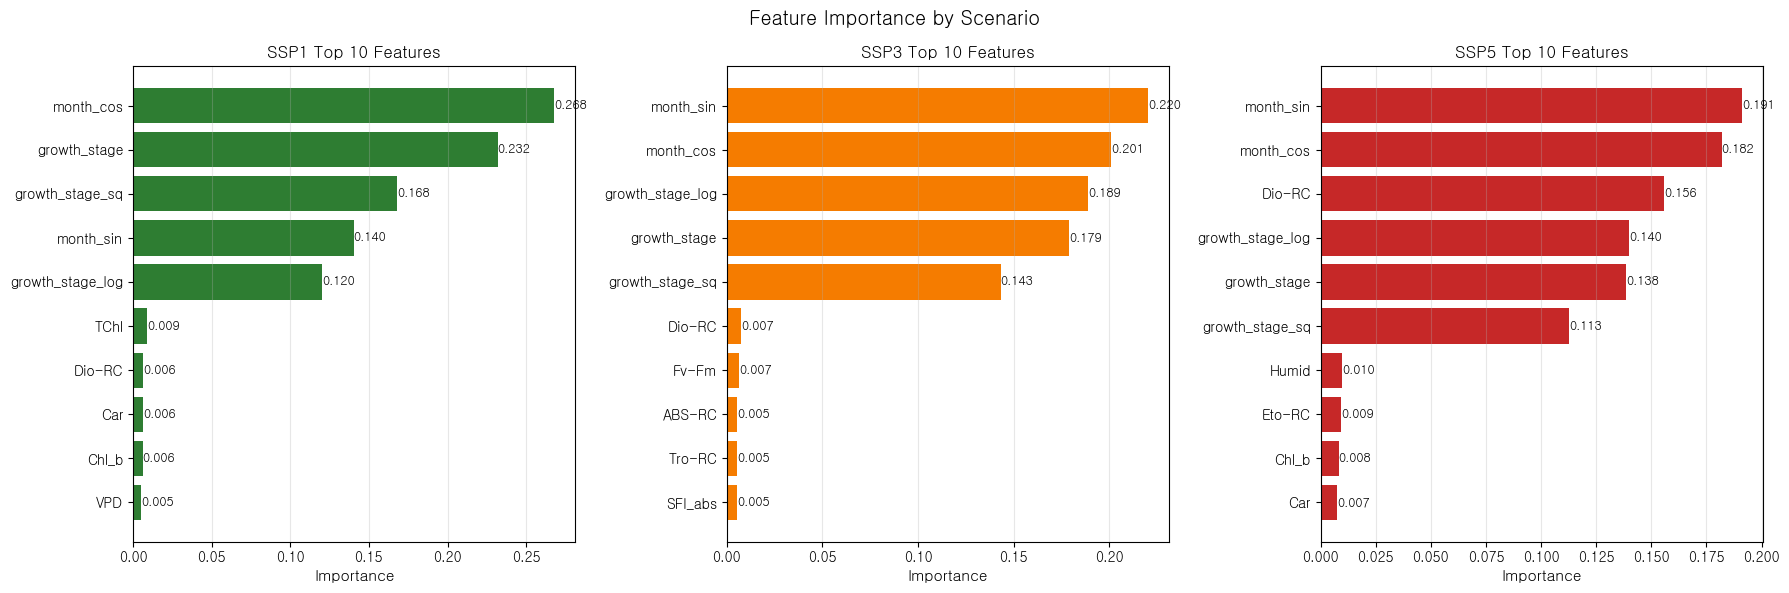

In [ ]:
# 5. 특성 중요도 비교 (시나리오별)
print("그래프 5: 특성 중요도 비교...")
fig5, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    ax = axes[idx]
    importance = feature_importance_all[scenario]
    top_idx = np.argsort(importance)[-10:]
    
    top_features = X_final.columns[top_idx]
    top_importance = importance[top_idx]
    
    bars = ax.barh(range(10), top_importance, color=colors_scenario[idx])
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_features, fontsize=10)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{scenario} Top 10 Features', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # 값 표시
    for i, (bar, val) in enumerate(zip(bars, top_importance)):
        ax.text(val, i, f'{val:.3f}', ha='left', va='center', fontsize=9)

plt.suptitle('Feature Importance by Scenario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

그래프 6: 교차검증 안정성...


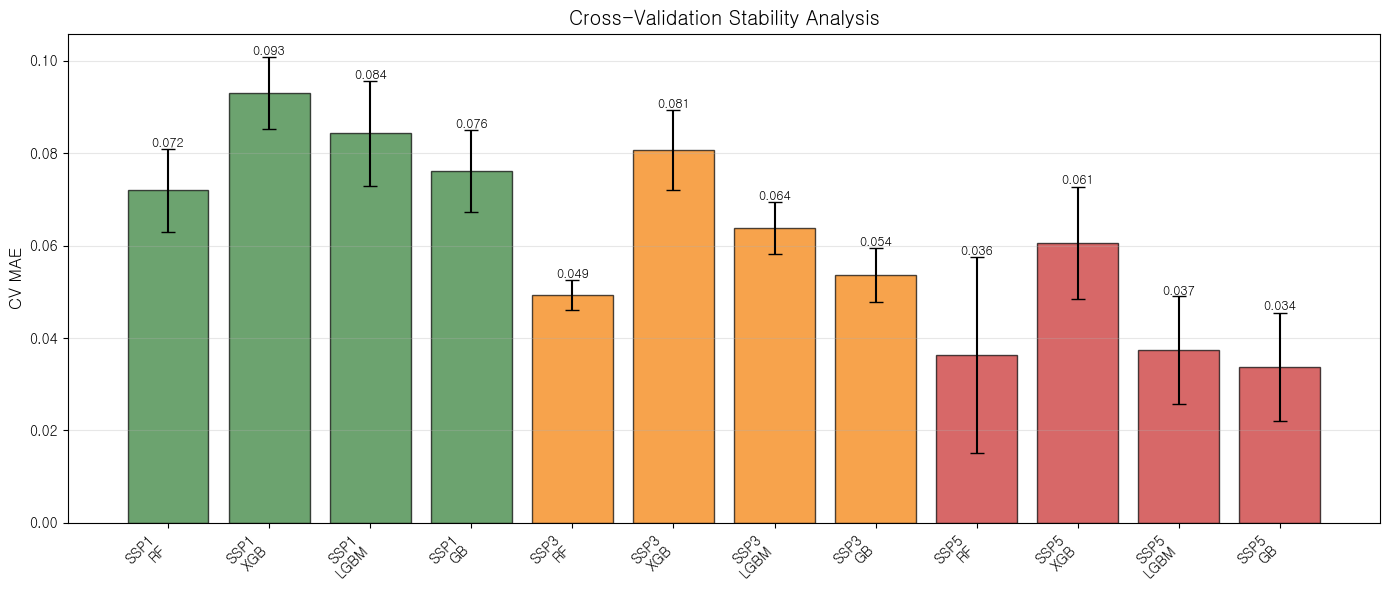

In [ ]:
# 6. 교차검증 안정성 분석
print("그래프 6: 교차검증 안정성...")
fig6, ax = plt.subplots(1, 1, figsize=(14, 6))
cv_data = []
positions = []
labels = []
colors = []
pos = 0

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    for model in ['RF', 'XGB', 'LGBM', 'GB']:
        if model in cv_results[scenario]:
            mean = cv_results[scenario][model]['mean']
            std = cv_results[scenario][model]['std']
            cv_data.append((mean, std))
            positions.append(pos)
            labels.append(f'{scenario}\n{model}')
            
            if scenario == 'SSP1':
                colors.append(colors_scenario[0])
            elif scenario == 'SSP3':
                colors.append(colors_scenario[1])
            else:
                colors.append(colors_scenario[2])
            pos += 1

means = [d[0] for d in cv_data]
stds = [d[1] for d in cv_data]

bars = ax.bar(positions, means, yerr=stds, capsize=5, 
              color=colors, alpha=0.7, edgecolor='black', linewidth=1)

# 값 표시
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('CV MAE', fontsize=12)
ax.set_title('Cross-Validation Stability Analysis', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

그래프 7: 예측 정확도...


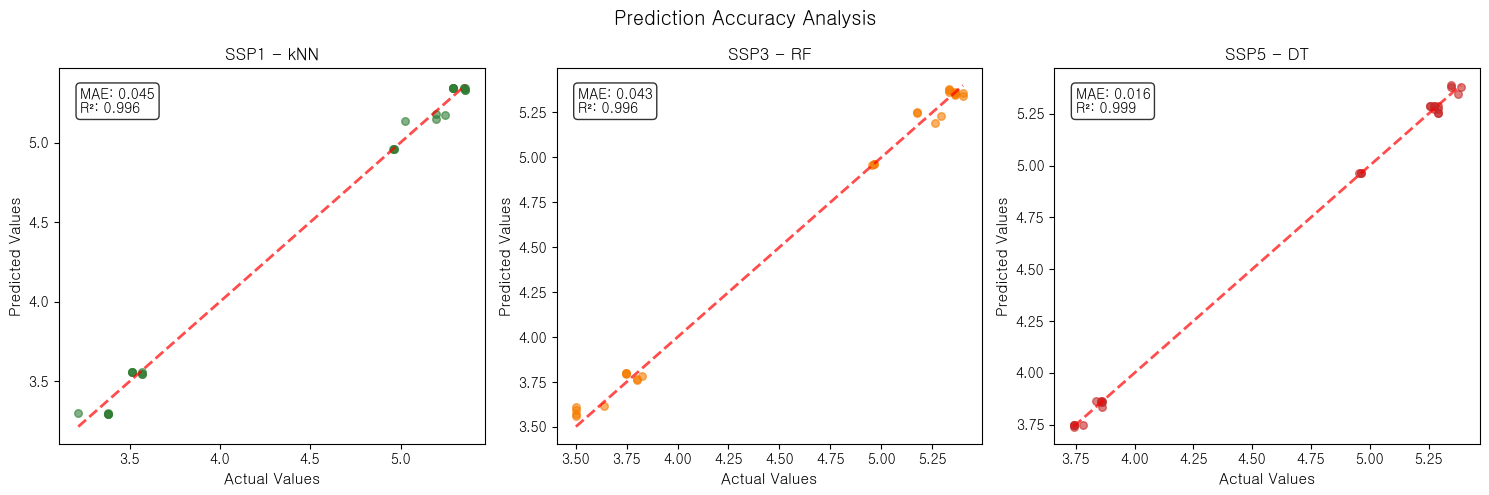

In [ ]:
# 7. 예측값 vs 실제값 (최고 모델)
print("그래프 7: 예측 정확도...")
fig7, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    ax = axes[idx]
    
    # 최고 모델로 예측
    best_name = best_models[scenario]['name']
    model = best_models[scenario]['model']
    scaler = best_models[scenario]['scaler']
    
    # 데이터 준비
    scenario_mask = scenarios == scenario
    X_scenario = X_final[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    
    # 모든 타겟 평균
    y_test_mean = y_test.mean(axis=1)
    y_pred_mean = y_pred.mean(axis=1)
    
    ax.scatter(y_test_mean, y_pred_mean, alpha=0.6, s=30, color=colors_scenario[idx])
    
    # 완벽한 예측선
    min_val = min(y_test_mean.min(), y_pred_mean.min())
    max_val = max(y_test_mean.max(), y_pred_mean.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, alpha=0.7)
    
    ax.set_xlabel('Actual Values', fontsize=11)
    ax.set_ylabel('Predicted Values', fontsize=11)
    ax.set_title(f'{scenario} - {best_name}', fontsize=12, fontweight='bold')
    
    # 성능 지표 표시
    mae = mean_absolute_error(y_test_mean, y_pred_mean)
    r2 = r2_score(y_test_mean, y_pred_mean)
    ax.text(0.05, 0.95, f'MAE: {mae:.3f}\nR²: {r2:.3f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Prediction Accuracy Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

그래프 8: 잔차 분석...


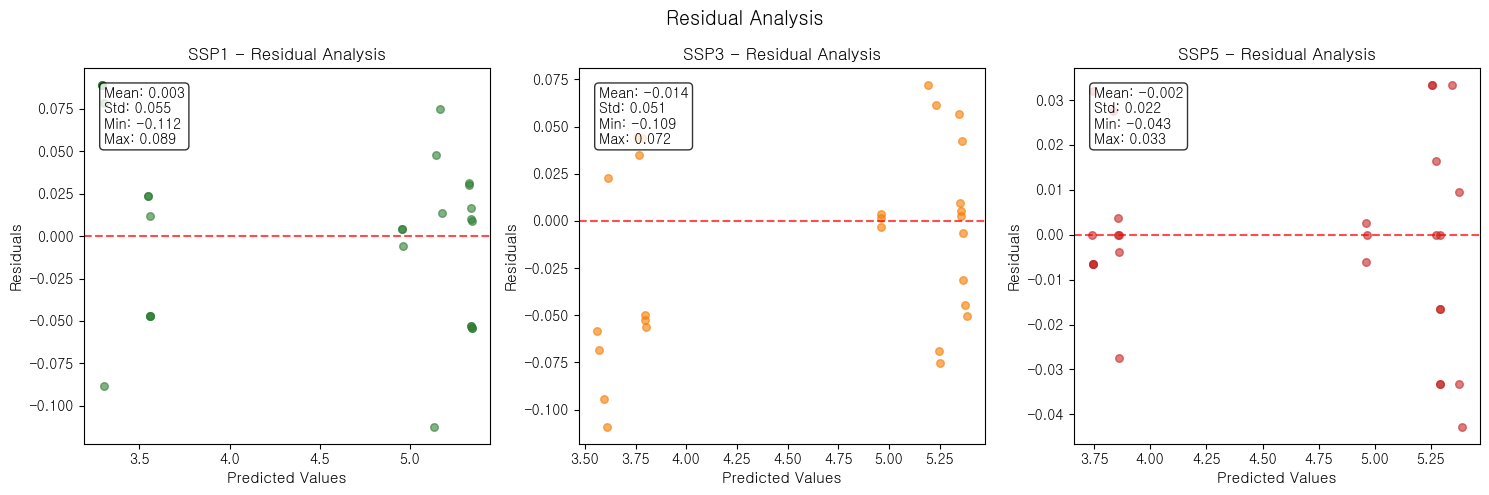

In [ ]:
# 8. 잔차 분석
print("그래프 8: 잔차 분석...")
fig8, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    ax = axes[idx]
    
    # 최고 모델로 예측
    best_name = best_models[scenario]['name']
    model = best_models[scenario]['model']
    scaler = best_models[scenario]['scaler']
    
    # 데이터 준비
    scenario_mask = scenarios == scenario
    X_scenario = X_final[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    
    # 잔차 계산
    y_test_mean = y_test.mean(axis=1)
    y_pred_mean = y_pred.mean(axis=1)
    residuals = y_test_mean - y_pred_mean
    
    ax.scatter(y_pred_mean, residuals, alpha=0.6, s=30, color=colors_scenario[idx])
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    ax.set_xlabel('Predicted Values', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'{scenario} - Residual Analysis', fontsize=12, fontweight='bold')
    
    # 잔차 통계
    ax.text(0.05, 0.95, 
           f'Mean: {residuals.mean():.3f}\nStd: {residuals.std():.3f}\nMin: {residuals.min():.3f}\nMax: {residuals.max():.3f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

그래프 9: MAPE 분포...


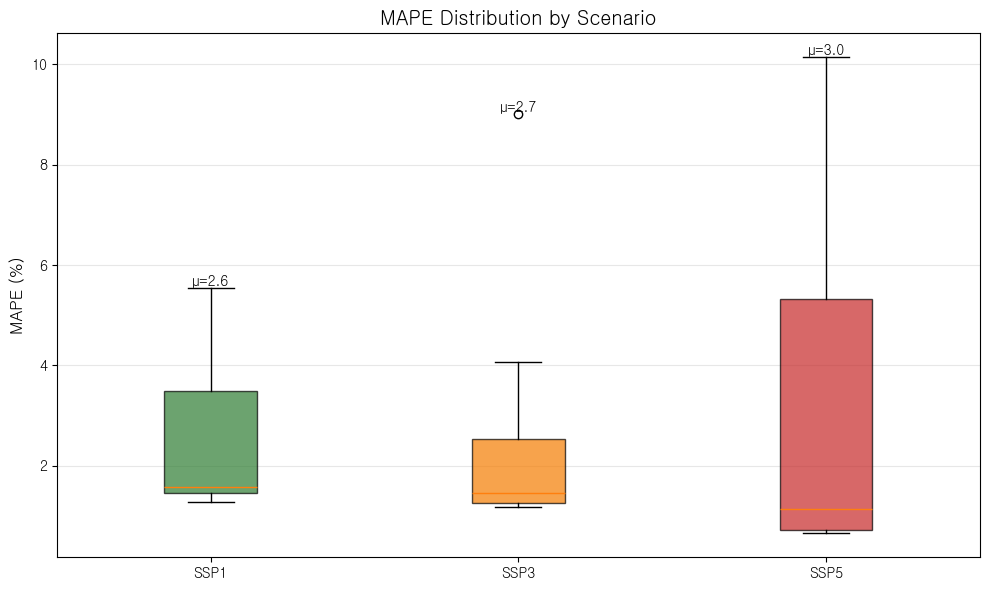

In [ ]:
# 9. MAPE 분포
print("그래프 9: MAPE 분포...")
fig9, ax = plt.subplots(1, 1, figsize=(10, 6))
mape_data = []
labels = []

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mape = [safe_float(scenario_results[scenario][model]['MAPE']) 
                     for model in base_models.keys()]
    mape_data.append(scenario_mape)
    labels.append(scenario)

bp = ax.boxplot(mape_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_scenario):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 평균값 표시
for i, data in enumerate(mape_data):
    ax.text(i+1, np.max(data), f'μ={np.mean(data):.1f}', 
           ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE Distribution by Scenario', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Original Data 결과 테이블 생성
# 테이블 데이터 구성
table_data = []
for model_name in base_models.keys():
    row_data = {'Model': model_name}
    
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        if model_name in scenario_results[scenario]:
            metrics = scenario_results[scenario][model_name]
            
            # 시나리오 이름 매핑
            scenario_label = {
                'SSP1': 'SSP1-2.6',
                'SSP3': 'SSP3-7.0', 
                'SSP5': 'SSP5-8.5'
            }[scenario]
            
            row_data[f'{scenario_label}_MAE'] = safe_float(metrics['MAE'])
            row_data[f'{scenario_label}_RMSE'] = safe_float(metrics['RMSE'])
            row_data[f'{scenario_label}_MAPE'] = safe_float(metrics['MAPE'])
    
    table_data.append(row_data)

# DataFrame 생성
results_df = pd.DataFrame(table_data)

# 테이블 포맷팅 및 출력
print("\n" + "="*140)
print(f"{'Data':<15} {'Model':<10} {'SSP1-2.6':^35} {'SSP3-7.0':^35} {'SSP5-8.5':^35}")
print(f"{'':^15} {'':^10} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("="*140)

for _, row in results_df.iterrows():
    print(f"{'Original':<15} {row['Model']:<10}", end="")
    
    for scenario in ['SSP1-2.6', 'SSP3-7.0', 'SSP5-8.5']:
        mae = row.get(f'{scenario}_MAE', 0)
        rmse = row.get(f'{scenario}_RMSE', 0)
        mape = row.get(f'{scenario}_MAPE', 0)
        print(f" {mae:<11.3f} {rmse:<11.3f} {mape:<11.3f}", end="")
    print()


Data            Model                   SSP1-2.6                            SSP3-7.0                            SSP5-8.5              
                           MAE          RMSE         MAPE         MAE          RMSE         MAPE         MAE          RMSE         MAPE        
Original        LinearR    0.070       0.112       1.568       0.052       0.079       1.179       0.033       0.047       0.720      
Original        Ridge      0.158       0.286       5.469       0.148       0.226       4.063       0.181       0.398       5.330      
Original        kNN        0.061       0.098       1.282       0.092       0.245       2.047       0.164       0.613       5.570      
Original        SVM        0.134       0.235       5.535       0.207       0.395       9.009       0.240       0.694       10.143     
Original        DT         0.068       0.135       1.452       0.059       0.101       1.403       0.031       0.054       0.649      
Original        RF         0.064       0.110 

In [ ]:
extended_metrics = ['MSE', 'MSLE', 'RMSLE', 'R2', 'PI']
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_label = {
        'SSP1': 'SSP1-2.6',
        'SSP3': 'SSP3-7.0',
        'SSP5': 'SSP5-8.5'
    }[scenario]
    
    print(f"\n{scenario_label} Scenario Extended Metrics:")
    print("-"*100)
    print(f"{'Model':<10} {'MSE':<12} {'MSLE':<12} {'RMSLE':<12} {'R2':<12} {'PI':<12}")
    print("-"*100)
    
    for model_name in base_models.keys():
        if model_name in scenario_results[scenario]:
            m = scenario_results[scenario][model_name]
            print(f"{model_name:<10} {safe_float(m['MSE']):<12.4f} {safe_float(m['MSLE']):<12.4f} "
                  f"{safe_float(m['RMSLE']):<12.4f} {safe_float(m['R2']):<12.4f} {safe_float(m['PI']):<12.4f}")


SSP1-2.6 Scenario Extended Metrics:
----------------------------------------------------------------------------------------------------
Model      MSE          MSLE         RMSLE        R2           PI          
----------------------------------------------------------------------------------------------------
LinearR    0.0126       0.0002       0.0155       0.9758       0.9954      
Ridge      0.0817       0.0052       0.0724       0.9499       0.9785      
kNN        0.0096       0.0002       0.0134       0.9798       0.9959      
SVM        0.0552       0.0029       0.0535       0.8962       0.9879      
DT         0.0182       0.0003       0.0182       0.9633       0.9939      
RF         0.0120       0.0002       0.0148       0.9742       0.9955      
GB         0.0157       0.0003       0.0169       0.9707       0.9940      
XGB        0.0657       0.0015       0.0387       0.8701       0.9641      
LGBM       0.0164       0.0003       0.0177       0.9687       0.9949      



In [ ]:
best_summary = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results[scenario].items(), 
               key=lambda x: safe_float(x[1]['MAE']))
    
    scenario_label = {
        'SSP1': 'SSP1-2.6',
        'SSP3': 'SSP3-7.0',
        'SSP5': 'SSP5-8.5'
    }[scenario]
    
    best_summary.append({
        'Scenario': scenario_label,
        'Best Model': best[0],
        'MAE': safe_float(best[1]['MAE']),
        'RMSE': safe_float(best[1]['RMSE']),
        'MAPE': safe_float(best[1]['MAPE']),
        'R2': safe_float(best[1]['R2']),
        'PI': safe_float(best[1]['PI'])
    })

best_df = pd.DataFrame(best_summary)
print(best_df.to_string(index=False))

Scenario Best Model      MAE     RMSE     MAPE       R2       PI
SSP1-2.6        kNN 0.060554 0.098192 1.281644 0.979802 0.995907
SSP3-7.0         RF 0.052189 0.079079 1.206469 0.972029 0.998292
SSP5-8.5         DT 0.031028 0.053795 0.649156 0.951797 0.999004


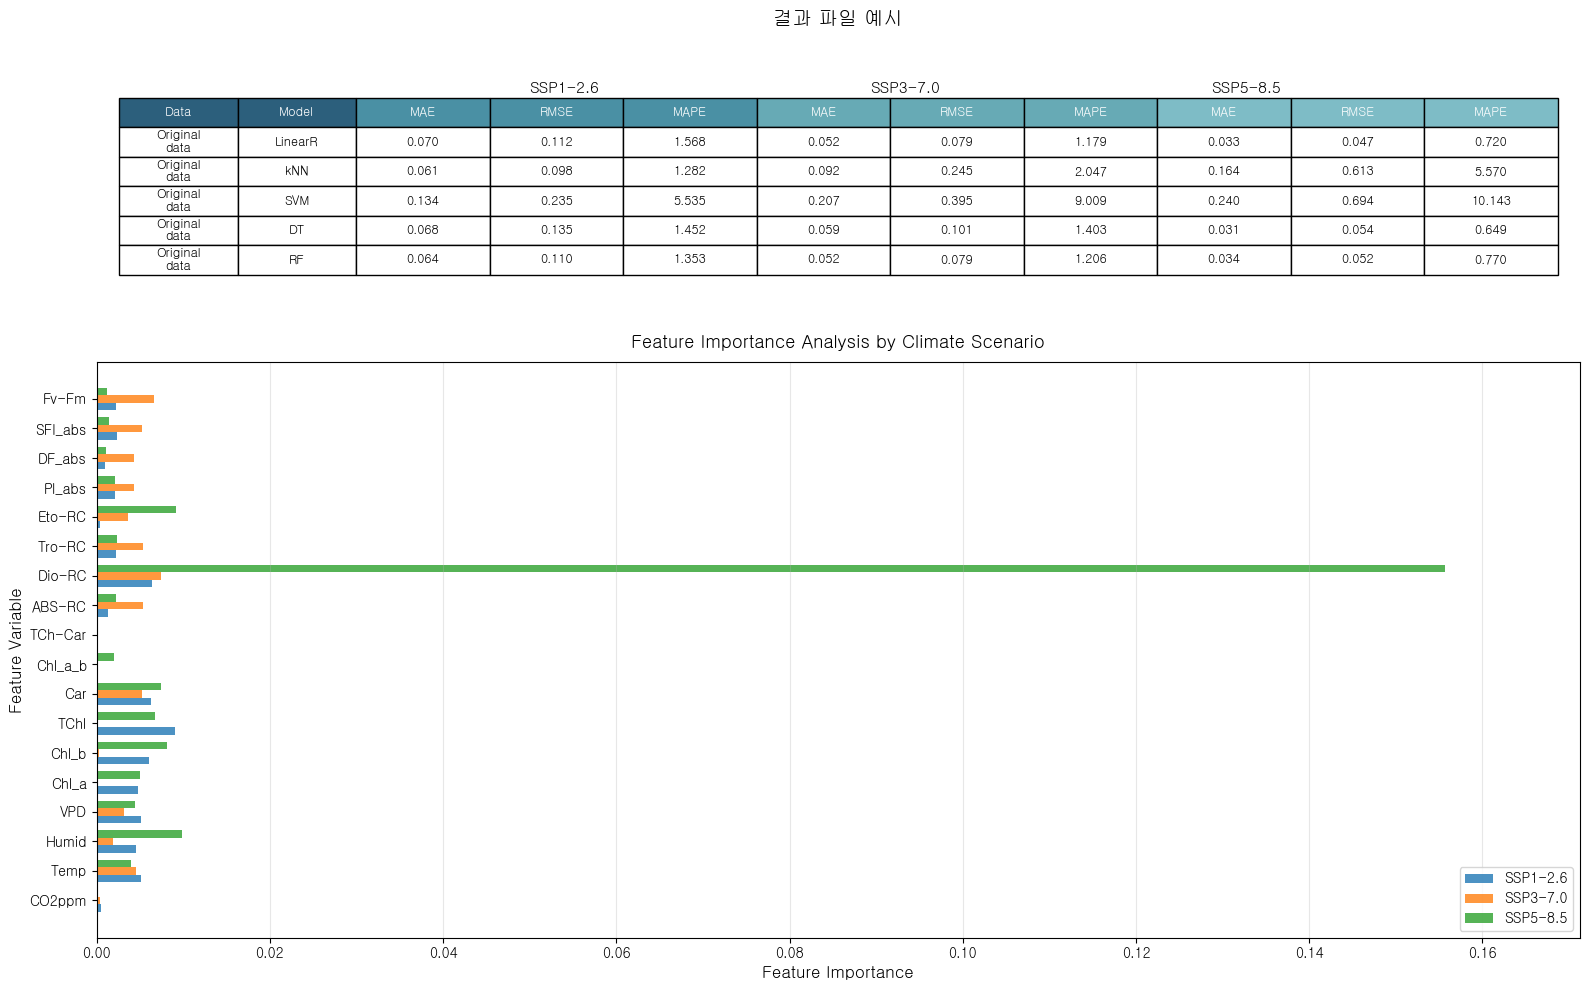

In [ ]:
# Figure 1: 결과 테이블 + Feature Importance (공모전 예시와 동일한 레이아웃)
fig = plt.figure(figsize=(16, 10))

# 상단: 테이블 영역
ax_table = plt.subplot2grid((3, 1), (0, 0), rowspan=1)
ax_table.axis('tight')
ax_table.axis('off')

# 테이블 데이터 준비
table_headers = ['Data', 'Model', 
                'MAE', 'RMSE', 'MAPE',  # SSP1-2.6
                'MAE', 'RMSE', 'MAPE',  # SSP3-7.0
                'MAE', 'RMSE', 'MAPE']  # SSP5-8.5

table_rows = []
for model_name in ['LinearR', 'kNN', 'SVM', 'DT', 'RF']:
    if model_name in base_models.keys():
        row = ['Original\ndata', model_name]
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            if model_name in scenario_results[scenario]:
                metrics = scenario_results[scenario][model_name]
                row.extend([
                    f"{safe_float(metrics['MAE']):.3f}",
                    f"{safe_float(metrics['RMSE']):.3f}",
                    f"{safe_float(metrics['MAPE']):.3f}"
                ])
            else:
                row.extend(['N/A', 'N/A', 'N/A'])
        table_rows.append(row)

# 테이블 생성
table = ax_table.table(cellText=table_rows, 
                       colLabels=table_headers,
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.08, 0.08] + [0.09]*9)

# 테이블 스타일링
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# 헤더 스타일
for i in range(len(table_headers)):
    if i < 2:
        table[(0, i)].set_facecolor('#2C5F7C')
    elif i < 5:
        table[(0, i)].set_facecolor('#4A90A4')
    elif i < 8:
        table[(0, i)].set_facecolor('#67AAB5')
    else:
        table[(0, i)].set_facecolor('#7EBCC6')
    table[(0, i)].set_text_props(weight='bold', color='white')

# 시나리오 라벨 추가
ax_table.text(0.315, 0.85, 'SSP1-2.6', transform=ax_table.transAxes, 
             fontsize=11, fontweight='bold', ha='center')
ax_table.text(0.545, 0.85, 'SSP3-7.0', transform=ax_table.transAxes,
             fontsize=11, fontweight='bold', ha='center')
ax_table.text(0.775, 0.85, 'SSP5-8.5', transform=ax_table.transAxes,
             fontsize=11, fontweight='bold', ha='center')

ax_table.set_title('결과 파일 예시', fontsize=14, fontweight='bold', pad=20)

# 하단: Feature Importance 그래프
ax_importance = plt.subplot2grid((3, 1), (1, 0), rowspan=2)

# Feature Importance 데이터 준비
features_to_plot = original_features  # 원본 특성만 표시

# 각 시나리오별 importance 가져오기
importance_data = {}
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    importance = feature_importance_all[scenario]
    feature_imp = {}
    for i, feat in enumerate(X_final.columns):
        if feat in features_to_plot:
            feature_imp[feat] = importance[i]
    importance_data[scenario] = feature_imp

# 그래프 그리기
y_pos = np.arange(len(features_to_plot))
bar_height = 0.25
colors = {'SSP1': '#1f77b4', 'SSP3': '#ff7f0e', 'SSP5': '#2ca02c'}
scenario_labels = {'SSP1': 'SSP1-2.6', 'SSP3': 'SSP3-7.0', 'SSP5': 'SSP5-8.5'}

for i, (scenario, color) in enumerate(colors.items()):
    values = [importance_data[scenario].get(feat, 0) for feat in features_to_plot]
    ax_importance.barh(y_pos + i * bar_height, values, bar_height, 
                      label=scenario_labels[scenario], color=color, alpha=0.8)

ax_importance.set_yticks(y_pos + bar_height)
ax_importance.set_yticklabels(features_to_plot)
ax_importance.set_xlabel('Feature Importance', fontsize=12)
ax_importance.set_ylabel('Feature Variable', fontsize=12)
ax_importance.set_title('Feature Importance Analysis by Climate Scenario', 
                        fontsize=13, fontweight='bold', pad=10)
ax_importance.legend(loc='lower right')
ax_importance.grid(axis='x', alpha=0.3)
ax_importance.set_xlim(0, max([max(importance_data[s].values()) for s in ['SSP1', 'SSP3', 'SSP5']]) * 1.1)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

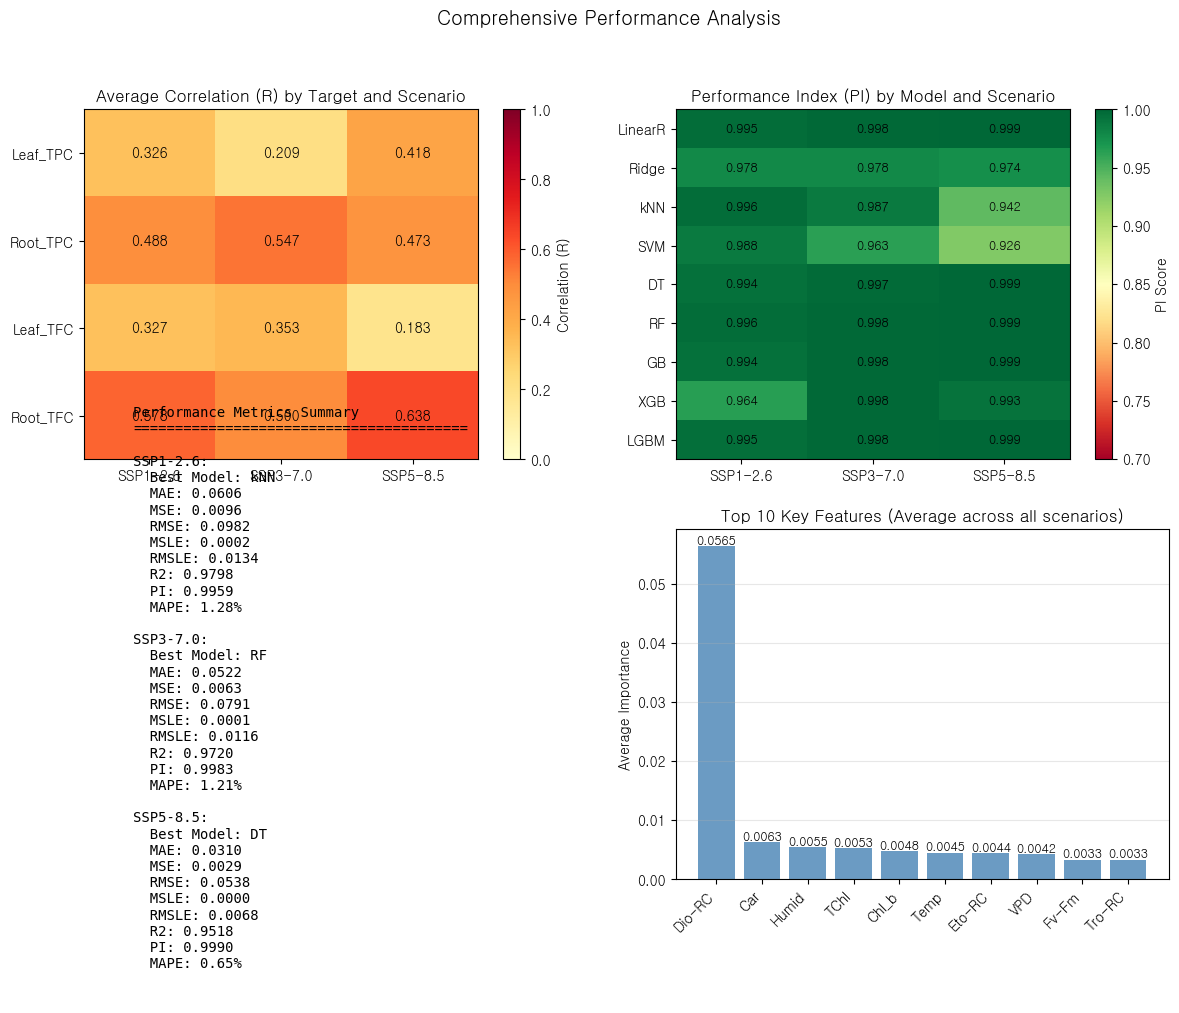

In [ ]:
# Figure 2: 상관관계 분석 결과
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2-1. 타겟별 상관관계 (R 값)
ax = axes[0, 0]
correlation_matrix = []
for target in target_names:
    row = []
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        scenario_mask = scenarios == scenario
        X_scenario = X_final[scenario_mask]
        y_scenario = y_targets[scenario_mask]
        
        # 전체 특성과의 평균 상관관계
        correlations = []
        for feat in original_features[:10]:  # 상위 10개 특성
            if feat in X_scenario.columns:
                corr, _ = pearsonr(X_scenario[feat], y_scenario[target])
                correlations.append(abs(corr))
        row.append(np.mean(correlations))
    correlation_matrix.append(row)

im = ax.imshow(correlation_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_xticklabels(['SSP1-2.6', 'SSP3-7.0', 'SSP5-8.5'])
ax.set_yticks(range(4))
ax.set_yticklabels(target_names)
ax.set_title('Average Correlation (R) by Target and Scenario', fontweight='bold')
plt.colorbar(im, ax=ax, label='Correlation (R)')

for i in range(4):
    for j in range(3):
        text = ax.text(j, i, f'{correlation_matrix[i][j]:.3f}',
                      ha="center", va="center", color="black")

# 2-2. Performance Index (PI) 히트맵
ax = axes[0, 1]
pi_matrix = []
model_names_short = ['LinearR', 'Ridge', 'kNN', 'SVM', 'DT', 'RF', 'GB', 'XGB', 'LGBM']
for model in model_names_short:
    if model in base_models.keys():
        row = []
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            if model in scenario_results[scenario]:
                row.append(safe_float(scenario_results[scenario][model]['PI']))
            else:
                row.append(0)
        pi_matrix.append(row)

im = ax.imshow(pi_matrix, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)
ax.set_xticks(range(3))
ax.set_xticklabels(['SSP1-2.6', 'SSP3-7.0', 'SSP5-8.5'])
ax.set_yticks(range(len(pi_matrix)))
ax.set_yticklabels([m for m in model_names_short if m in base_models.keys()])
ax.set_title('Performance Index (PI) by Model and Scenario', fontweight='bold')
plt.colorbar(im, ax=ax, label='PI Score')

for i in range(len(pi_matrix)):
    for j in range(3):
        if pi_matrix[i][j] > 0:
            text = ax.text(j, i, f'{pi_matrix[i][j]:.3f}',
                          ha="center", va="center", color="black", fontsize=9)

# 2-3. 모든 성능 지표 종합 (레이더 차트)
ax = axes[1, 0]
ax.axis('off')

# 텍스트로 성능 지표 요약
summary_text = "Performance Metrics Summary\n" + "="*40 + "\n\n"
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_label = {
        'SSP1': 'SSP1-2.6',
        'SSP3': 'SSP3-7.0',
        'SSP5': 'SSP5-8.5'
    }[scenario]
    
    best = min(scenario_results[scenario].items(), 
               key=lambda x: safe_float(x[1]['MAE']))
    
    summary_text += f"{scenario_label}:\n"
    summary_text += f"  Best Model: {best[0]}\n"
    summary_text += f"  MAE: {safe_float(best[1]['MAE']):.4f}\n"
    summary_text += f"  MSE: {safe_float(best[1]['MSE']):.4f}\n"
    summary_text += f"  RMSE: {safe_float(best[1]['RMSE']):.4f}\n"
    summary_text += f"  MSLE: {safe_float(best[1]['MSLE']):.4f}\n"
    summary_text += f"  RMSLE: {safe_float(best[1]['RMSLE']):.4f}\n"
    summary_text += f"  R2: {safe_float(best[1]['R2']):.4f}\n"
    summary_text += f"  PI: {safe_float(best[1]['PI']):.4f}\n"
    summary_text += f"  MAPE: {safe_float(best[1]['MAPE']):.2f}%\n\n"

ax.text(0.1, 0.5, summary_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='center', fontfamily='monospace')

# 2-4. 핵심 인자 순위
ax = axes[1, 1]

# 모든 시나리오 평균 중요도 계산
avg_importance = {}
for feat in original_features:
    feat_importance = []
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        importance = feature_importance_all[scenario]
        if feat in X_final.columns:
            idx = list(X_final.columns).index(feat)
            feat_importance.append(importance[idx])
    if feat_importance:
        avg_importance[feat] = np.mean(feat_importance)

# 상위 10개 특성
top_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:10]
features = [f[0] for f in top_features]
values = [f[1] for f in top_features]

bars = ax.bar(range(10), values, color='steelblue', alpha=0.8)
ax.set_xticks(range(10))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Average Importance')
ax.set_title('Top 10 Key Features (Average across all scenarios)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 값 표시
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comprehensive Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

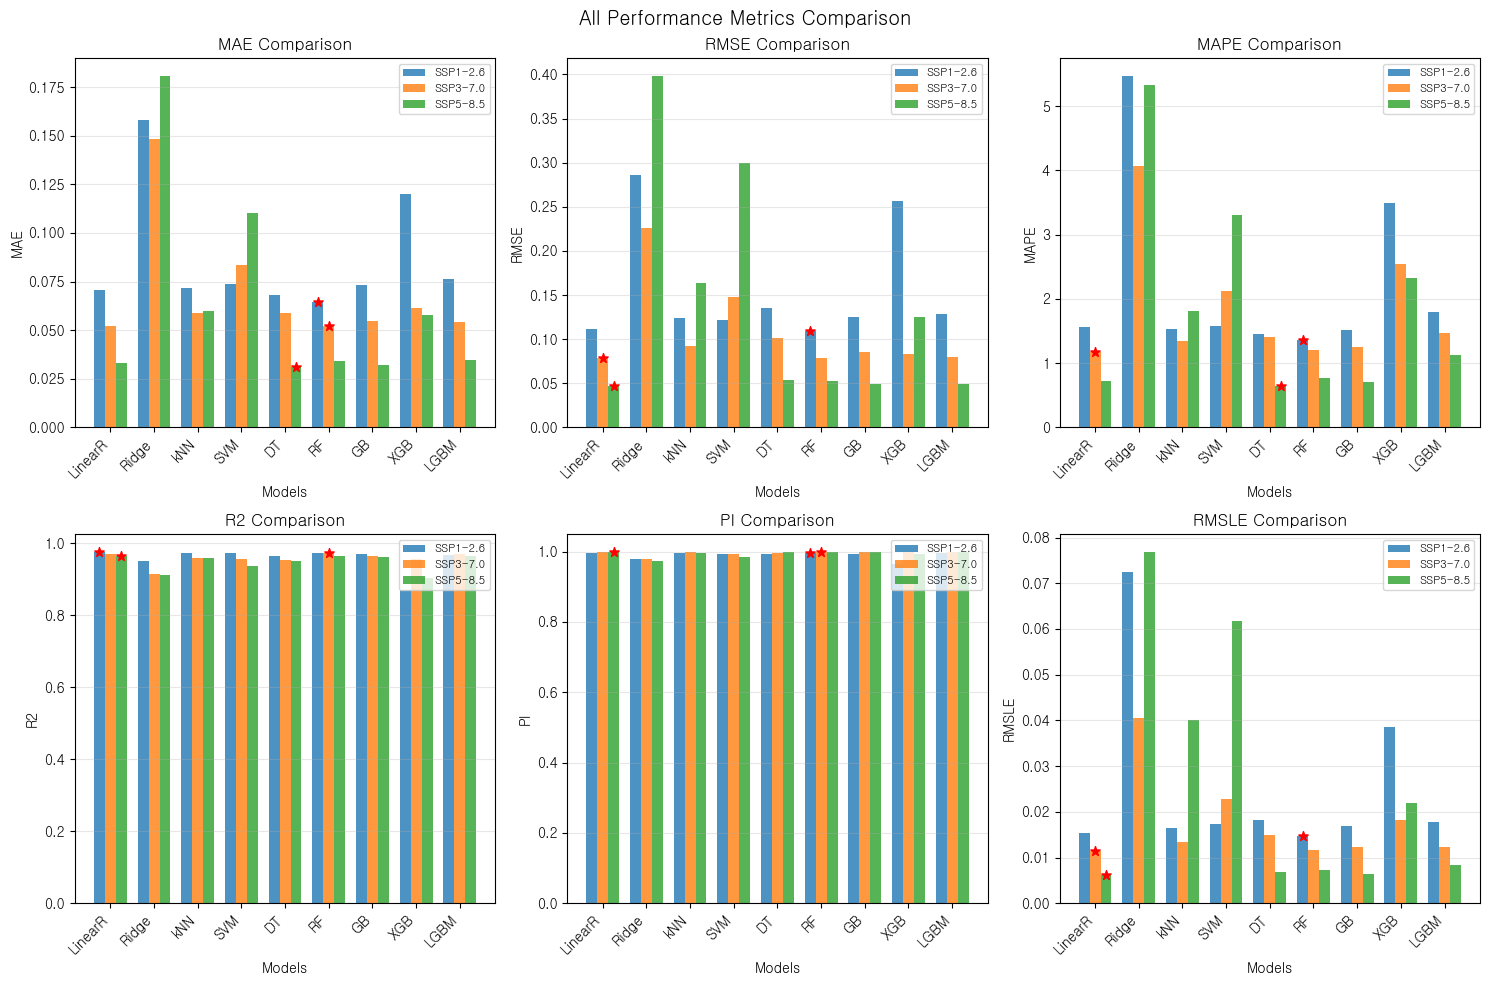

In [ ]:
# Figure 3: 성능 지표 비교 (막대 그래프)
fig3, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'R2', 'PI', 'RMSLE']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    # 데이터 준비
    model_names = list(base_models.keys())
    x = np.arange(len(model_names))
    width = 0.25
    
    for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
        values = []
        for model in model_names:
            if model in scenario_results[scenario]:
                values.append(safe_float(scenario_results[scenario][model][metric]))
            else:
                values.append(0)
        
        scenario_label = {'SSP1': 'SSP1-2.6', 'SSP3': 'SSP3-7.0', 'SSP5': 'SSP5-8.5'}[scenario]
        bars = ax.bar(x + i*width, values, width, label=scenario_label, alpha=0.8)
        
        # 최소/최대값 표시
        if metric in ['MAE', 'RMSE', 'MAPE', 'RMSLE']:
            best_idx = np.argmin(values)
        else:
            best_idx = np.argmax(values)
        
        ax.scatter(x[best_idx] + i*width, values[best_idx], 
                  color='red', s=50, zorder=5, marker='*')
    
    ax.set_xlabel('Models')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.legend(loc='best', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('All Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 최종 

In [ ]:
print("\n🏆 최종 권장사항:")
print("-"*50)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best_name = best_models[scenario]['name']
    best_metrics = scenario_results[scenario][best_name]
    
    print(f"\n{scenario} 시나리오:")
    print(f"  권장 모델: {best_name}")
    print(f"  MAE: {safe_float(best_metrics['MAE']):.4f}")
    print(f"  R2: {safe_float(best_metrics['R2']):.4f}")
    print(f"  PI: {safe_float(best_metrics['PI']):.4f}")
    print(f"  MAPE: {safe_float(best_metrics['MAPE']):.2f}%")
    
    if best_models[scenario]['params']:
        print(f"  최적 파라미터:")
        for param, value in best_models[scenario]['params'].items():
            print(f"    - {param}: {value}")



🏆 최종 권장사항:
--------------------------------------------------

SSP1 시나리오:
  권장 모델: RF
  MAE: 0.0645
  R2: 0.9742
  PI: 0.9955
  MAPE: 1.35%

SSP3 시나리오:
  권장 모델: RF
  MAE: 0.0522
  R2: 0.9720
  PI: 0.9983
  MAPE: 1.21%

SSP5 시나리오:
  권장 모델: DT
  MAE: 0.0310
  R2: 0.9518
  PI: 0.9990
  MAPE: 0.65%


In [ ]:
# 모든 시나리오에서 공통적으로 중요한 특성 찾기
common_important_features = {}
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    importance = feature_importance_all[scenario]
    top_idx = np.argsort(importance)[-10:]
    for idx in top_idx:
        feat = X_final.columns[idx]
        if feat not in common_important_features:
            common_important_features[feat] = []
        common_important_features[feat].append(importance[idx])

# 평균 중요도 계산 및 정렬
avg_importance = {feat: np.mean(values) for feat, values in common_important_features.items()}
sorted_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)

print("모든 시나리오에서 중요한 특성 Top 10:")
for i, (feat, imp) in enumerate(sorted_features[:10], 1):
    count = len(common_important_features[feat])
    print(f"  {i:2d}. {feat:25s}: {imp:.4f} (등장 횟수: {count}/3)")

모든 시나리오에서 중요한 특성 Top 10:
   1. month_cos                : 0.2170 (등장 횟수: 3/3)
   2. month_sin                : 0.1839 (등장 횟수: 3/3)
   3. growth_stage             : 0.1832 (등장 횟수: 3/3)
   4. growth_stage_log         : 0.1496 (등장 횟수: 3/3)
   5. growth_stage_sq          : 0.1413 (등장 횟수: 3/3)
   6. Dio-RC                   : 0.0565 (등장 횟수: 3/3)
   7. Humid                    : 0.0099 (등장 횟수: 1/3)
   8. Eto-RC                   : 0.0092 (등장 횟수: 1/3)
   9. TChl                     : 0.0090 (등장 횟수: 1/3)
  10. Chl_b                    : 0.0071 (등장 횟수: 2/3)
